# Logistic Regression

Ky notebook trajnon dhe vlereson modelin Logistic Regression per klasifikimin e cmimit te shtepive ne tri klasa: `Low`, `Medium`, `High`.

Per kete model perdoren dataset-et e klasifikimit te krijuara ne notebook-un `04_scaling_train_val_test_split.ipynb`:

- `train_dataset.csv`
- `val_dataset.csv`
- `test_dataset.csv`

Keto dataset-e jane te shkallezuara dhe kane target-in `price_class`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

sns.set_theme(style="whitegrid")


## 1. Leximi i dataset-eve

Per Logistic Regression perdorim dataset-et e shkallezuara te klasifikimit. Nuk perdorim dataset-et `regression`, sepse ato kane target numerik `price`, ndersa Logistic Regression kerkon target kategorik.

In [2]:
data_dir = Path("../../data/processed")

train_df = pd.read_csv(data_dir / "train_dataset.csv")
val_df = pd.read_csv(data_dir / "val_dataset.csv")
test_df = pd.read_csv(data_dir / "test_dataset.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (12810, 53)
Validation shape: (4267, 53)
Test shape: (4279, 53)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,is_luxury_grade,is_high_view,is_premium,waterfront_grade,waterfront_sqft_living,view_grade,view_sqft_living,grade_lat_bin,grade_location_cluster,price_class
0,-0.400877,-1.474831,-1.014044,-0.225976,-0.905392,-0.073053,-0.297197,-0.637474,-0.552387,-0.736541,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-0.565504,-0.413012,Low
1,-0.400877,0.205526,-0.386572,-0.196899,0.948224,-0.073053,-0.297197,-0.637474,-0.552387,-0.057074,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-1.675403,-0.265497,Low
2,-0.400877,-1.474831,-0.310337,-0.180706,-0.905392,-0.073053,-0.297197,-0.637474,-0.552387,-0.901645,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-0.565504,-1.150589,Low
3,-0.400877,0.541597,1.777328,-0.122849,-0.905392,-0.073053,-0.297197,-0.637474,0.332676,0.127080,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,0.544396,1.905088,High
4,-1.515537,-1.474831,-1.037501,-0.217270,-0.905392,-0.073053,-0.297197,0.886894,-0.552387,-1.142951,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,0.544396,-0.855558,Medium


## 2. Ndarja e veqorive dhe target-it

In [3]:
target_col = "price_class"
class_labels = ["Low", "Medium", "High"]

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print("Features:", X_train.shape[1])
print("Classes:", class_labels)
print("\nTrain class distribution:")
print(y_train.value_counts().reindex(class_labels, fill_value=0))


Features: 52
Classes: ['Low', 'Medium', 'High']

Train class distribution:
price_class
Low       4307
Medium    4279
High      4224
Name: count, dtype: int64


## 3. Model baseline

Fillimisht trajnojme nje Logistic Regression pa tuning, qe te kemi nje baseline.

In [4]:
baseline_model = LogisticRegression(max_iter=2000, random_state=42)
baseline_model.fit(X_train, y_train)

baseline_val_pred = baseline_model.predict(X_val)

print("Baseline validation accuracy:", accuracy_score(y_val, baseline_val_pred))
print("Baseline validation F1 macro:", f1_score(y_val, baseline_val_pred, average="macro"))
print("\nClassification report:")
print(classification_report(
    y_val,
    baseline_val_pred,
    labels=class_labels,
    zero_division=0
))


Baseline validation accuracy: 0.8087649402390438
Baseline validation F1 macro: 0.8089320287561196

Classification report:
              precision    recall  f1-score   support

         Low       0.87      0.85      0.86      1442
      Medium       0.70      0.74      0.72      1390
        High       0.86      0.84      0.85      1435

    accuracy                           0.81      4267
   macro avg       0.81      0.81      0.81      4267
weighted avg       0.81      0.81      0.81      4267



## 4. Hyperparameter tuning

Testojme disa vlera per C, ndersa solver, penalty dhe class_weight mbahen te fiksuara. Si metrike perdorim f1_macro sepse kemi tri klasa dhe duam qe secila klase te kete rendesi te barabarte.

In [5]:
log_reg = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    random_state=42,
    class_weight=None
)

param_grid = {
    "C": [0.01, 0.1, 1, 5, 10, 20, 50, 100],
}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

def create_logistic_regression_model():
    return LogisticRegression(
        solver="lbfgs",
        max_iter=3000,
        random_state=42,
        class_weight=None,
        **grid_search.best_params_
    )

print("Best parameters:")
print(grid_search.best_params_)
print("Best CV F1 macro:", grid_search.best_score_)


Best parameters:
{'C': 5}
Best CV F1 macro: 0.7982561826380313


## 5. Eksperiment me zgjedhje veqorish

Per kerkesen e projektit mbi zgjedhjen/reduktimin e veqorive, krahasojme modelin me te gjitha veqorite kundrejt `SelectKBest`. Kjo metode zgjedh veqorite me lidhjen me te forte statistikore me target-in.

In [6]:
k_values = [10, 15, 20, X_train.shape[1]]
feature_selection_results = []

for k in k_values:
    model = create_logistic_regression_model()

    if k == X_train.shape[1]:
        X_train_used = X_train
        X_val_used = X_val
        selected_features = list(X_train.columns)
        label = "all_features"
    else:
        selector = SelectKBest(score_func=f_classif, k=k)
        X_train_used = selector.fit_transform(X_train, y_train)
        X_val_used = selector.transform(X_val)
        selected_features = list(X_train.columns[selector.get_support()])
        label = f"select_k_best_{k}"

    model.fit(X_train_used, y_train)
    val_pred = model.predict(X_val_used)

    feature_selection_results.append({
        "experiment": label,
        "features_used": k,
        "accuracy": accuracy_score(y_val, val_pred),
        "precision_macro": precision_score(y_val, val_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, val_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_val, val_pred, average="macro"),
        "selected_features": selected_features,
    })

feature_selection_df = pd.DataFrame(feature_selection_results).sort_values("f1_macro", ascending=False)

feature_selection_df[[
    "experiment",
    "features_used",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro"
]]


,experiment,features_used,accuracy,precision_macro,recall_macro,f1_macro
3,all_features,52,0.808765,0.810523,0.807986,0.808962
2,select_k_best_20,20,0.781580,0.785543,0.780857,0.782522
1,select_k_best_15,15,0.779705,0.782765,0.778893,0.780348
0,select_k_best_10,10,0.717835,0.727243,0.716991,0.719722


### Interpretim: pse `all_features` doli me mire

Nga eksperimenti me `SelectKBest`, rezultati me i mire ne validation u arrit duke perdorur te gjitha vecorite (`all_features`). Kjo tregon se per Logistic Regression, edhe vecorite qe nuk jane ne top 10, 15 ose 20 sipas testit statistikor mund te kontribuojne kur kombinohen bashke ne nje model linear.

`SelectKBest` zgjedh vecorite individualisht sipas lidhjes se tyre me target-in, por nuk kap gjithmone mire efektin e kombinimeve mes vecorive. Ne kete dataset ka shume vecori te krijuara nga feature engineering, si kombinime te lokacionit, madhesise dhe `grade`. Edhe nese disa prej tyre duken me pak te rendesishme individualisht, ato mund te ndihmojne modelin ne ndarjen e klasave `Low`, `Medium` dhe `High`.

Per kete arsye, modeli final perdor `all_features`, sepse dha F1 Macro me te larte ne validation dhe ruan me shume informacion nga dataset-i.

## 6. Krahasimi Train vs Validation dhe kontrolli per overfitting

Para vleresimit final ne test set, krahasojme performancen e konfigurimit me te mire ne train dhe validation. Nese performanca ne train eshte shume me e larte se ne validation, modeli ka shenja overfitting. Per Logistic Regression pritet zakonisht gap me i vogel se modelet me peme, sepse modeli eshte linear dhe me i kufizuar.

In [7]:
best_feature_experiment = feature_selection_df.iloc[0]
best_k = int(best_feature_experiment["features_used"])

val_check_model = create_logistic_regression_model()

if best_feature_experiment["experiment"] == "all_features":
    X_train_check = X_train
    X_val_check = X_val
else:
    val_selector = SelectKBest(score_func=f_classif, k=best_k)
    X_train_check = val_selector.fit_transform(X_train, y_train)
    X_val_check = val_selector.transform(X_val)

val_check_model.fit(X_train_check, y_train)

train_pred_check = val_check_model.predict(X_train_check)
val_pred_check = val_check_model.predict(X_val_check)

train_vs_val_results = pd.DataFrame([
    {
        "Dataset": "Train",
        "Accuracy": accuracy_score(y_train, train_pred_check),
        "F1 Macro": f1_score(y_train, train_pred_check, average="macro", zero_division=0),
        "Precision Macro": precision_score(y_train, train_pred_check, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_train, train_pred_check, average="macro", zero_division=0),
    },
    {
        "Dataset": "Validation",
        "Accuracy": accuracy_score(y_val, val_pred_check),
        "F1 Macro": f1_score(y_val, val_pred_check, average="macro", zero_division=0),
        "Precision Macro": precision_score(y_val, val_pred_check, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_val, val_pred_check, average="macro", zero_division=0),
    },
]).round(4)

display(train_vs_val_results)

f1_gap = train_vs_val_results.loc[0, "F1 Macro"] - train_vs_val_results.loc[1, "F1 Macro"]
print("F1 Macro gap train-validation:", round(f1_gap, 4))

if f1_gap > 0.10:
    print("Ka shenja te mundshme overfitting: performanca ne train eshte dukshem me e larte se ne validation.")
else:
    print("Nuk ka shenja te forta overfitting sipas F1 Macro: train dhe validation jane relativisht afer.")

,Dataset,Accuracy,F1 Macro,Precision Macro,Recall Macro
0,Train,0.7999,0.8014,0.8035,0.800
1,Validation,0.8088,0.8090,0.8105,0.808


F1 Macro gap train-validation: -0.0076
Nuk ka shenja te forta overfitting sipas F1 Macro: train dhe validation jane relativisht afer.


### Interpretim: overfitting

Nga krahasimi train vs validation shihet se Logistic Regression nuk shfaq shenja overfitting. Train F1 Macro eshte 0.8014, ndersa Validation F1 Macro eshte 0.8090, pra validation performon pak me mire se train. F1 Macro gap eshte -0.0076, qe do te thote se nuk ka diference problematike ku train performon shume me mire se validation.

Ky rezultat tregon se modeli gjeneralizon mire dhe nuk eshte pershtatur teper me train set-in. Kjo eshte e pritshme per Logistic Regression, sepse eshte model linear dhe me i kufizuar se modelet me peme. Diferenca e vogel ne favor te validation mund te ndodhe per shkak te ndarjes se te dhenave ose sepse validation set ka raste pak me te lehta per t'u klasifikuar.

Per kete arsye, modeli konsiderohet stabil dhe pa shenja te forta overfitting.

## 7. Vleresimi final ne test set
 
 Pasi modeli dhe numri i veqorive zgjidhen duke perdorur train/validation, vleresimi final behet mbi test set.

In [8]:
best_feature_experiment = feature_selection_df.iloc[0]
best_k = int(best_feature_experiment["features_used"])

X_train_final = pd.concat([X_train, X_val], ignore_index=True)
y_train_final = pd.concat([y_train, y_val], ignore_index=True)

final_model = create_logistic_regression_model()

if best_feature_experiment["experiment"] == "all_features":
    X_train_final_used = X_train_final
    X_test_used = X_test
    final_selected_features = list(X_train.columns)
else:
    final_selector = SelectKBest(score_func=f_classif, k=best_k)
    X_train_final_used = final_selector.fit_transform(X_train_final, y_train_final)
    X_test_used = final_selector.transform(X_test)
    final_selected_features = list(X_train.columns[final_selector.get_support()])

final_model.fit(X_train_final_used, y_train_final)

test_pred = final_model.predict(X_test_used)

test_metrics = {
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, test_pred),
    "precision_macro": precision_score(y_test, test_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, test_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, test_pred, average="macro"),
    "best_params": grid_search.best_params_,
    "features_used": best_k,
    "best_feature_experiment": best_feature_experiment["experiment"],
    "trained_on": "train + validation",
}

pd.DataFrame([test_metrics])


,model,accuracy,precision_macro,recall_macro,f1_macro,best_params,features_used,best_feature_experiment,trained_on
0,Logistic Regression,0.801122,0.805405,0.800841,0.802431,{'C': 5},52,all_features,train + validation


### Interpretim: performanca ne test

Rezultatet e test set-it jane vleresimi final i Logistic Regression, sepse test set nuk eshte perdorur per zgjedhjen e parametrave ose zgjedhjen e vecorive. Modeli final u trajnua me train + validation dhe pastaj u vleresua vetem nje here ne test set.

Modeli final perdori parametrin me te mire `C = 5` dhe te gjitha vecorite (`all_features`, 52 features). Kjo do te thote se eksperimenti me zgjedhje vecorish tregoi qe ruajtja e te gjitha features dha performancen me te mire per Logistic Regression.

Ne test set, modeli arriti Accuracy = 0.8011, Precision Macro = 0.8054, Recall Macro = 0.8008 dhe F1 Macro = 0.8024. Keto rezultate tregojne performance solide dhe te balancuar mes tri klasave `Low`, `Medium` dhe `High`.

`F1 Macro` eshte metrika kryesore ketu, sepse jep peshe te barabarte per secilen klase. Vlera F1 Macro = 0.8024 tregon se Logistic Regression eshte baseline i forte dhe i interpretueshem. Megjithate, si model linear, ai mund te mos kape marredhenie jo-lineare mes vecorive dhe cmimit aq mire sa modele me komplekse si Random Forest.

In [9]:
print(classification_report(
    y_test,
    test_pred,
    labels=class_labels,
    zero_division=0
))


              precision    recall  f1-score   support

         Low       0.88      0.83      0.86      1461
      Medium       0.69      0.74      0.71      1412
        High       0.85      0.83      0.84      1406

    accuracy                           0.80      4279
   macro avg       0.81      0.80      0.80      4279
weighted avg       0.81      0.80      0.80      4279



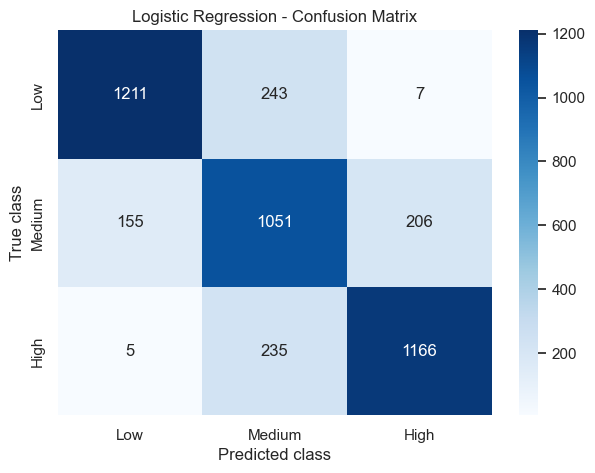

In [10]:
cm = confusion_matrix(y_test, test_pred, labels=class_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


### Interpretim: confusion matrix

Confusion matrix tregon se Logistic Regression klasifikon mire klasat ekstreme `Low` dhe `High`. Modeli parashikoi sakte 1211 raste `Low` dhe 1166 raste `High`. Po ashtu, gabimet direkte mes klasave ekstreme jane shume te vogla: vetem 7 raste `Low` u parashikuan si `High`, dhe vetem 5 raste `High` u parashikuan si `Low`. Kjo tregon se modeli arrin te dalloje mire cmimet e uleta nga cmimet e larta.

Gabimet kryesore ndodhin te klasa `Medium`. Modeli parashikoi sakte 1051 raste `Medium`, por 155 raste `Medium` u parashikuan si `Low` dhe 206 raste `Medium` u parashikuan si `High`. Kjo tregon se klasa `Medium` ka mbivendosje me dy klasat e tjera dhe eshte me e veshtira per t'u ndare qarte.

Gjithashtu, shume raste nga klasat ekstreme kalojne drejt `Medium`: 243 raste `Low` u parashikuan si `Medium`, dhe 235 raste `High` u parashikuan si `Medium`. Kjo eshte e pritshme, sepse Logistic Regression eshte model linear dhe mund te kete veshtiresi ne ndarjen e rasteve qe ndodhen afer kufijve mes klasave.

Ne pergjithesi, modeli ben pak gabime ekstreme (`Low` si `High` ose `High` si `Low`), por ka me shume konfuzion rreth klases `Medium`.

## 8. Interpretueshmeria e modelit - Feature Importance
 
 Pasi Logistic Regression eshte model linear, koeficientet e modelit mund te perdoren per te kuptuar ndikimin e seciles veÃ§ori ne klasifikim.  
 Koeficientet pozitive tregojne se nje veqori e shtyn modelin me shume drejt asaj klase, ndersa koeficientet negative e largojne modelin nga ajo klase.
 
 Meqenese dataset-i eshte i shkallezuar, koeficientet mund te krahasohen me mire mes veqorive.

In [11]:
coef_df = pd.DataFrame(
    final_model.coef_,
    columns=final_selected_features,
    index=final_model.classes_
)

coef_df

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,location_cluster,is_luxury_grade,is_high_view,is_premium,waterfront_grade,waterfront_sqft_living,view_grade,view_sqft_living,grade_lat_bin,grade_location_cluster
High,-0.171324,0.238016,-0.720273,0.216796,-0.123449,0.132218,-0.025922,0.354536,0.784761,-0.403766,...,-0.344573,-0.097750,0.023742,-0.055143,0.679155,-0.604415,0.330758,0.226539,-1.062500,0.496068
Low,0.295618,-0.278466,0.473927,-0.229595,0.083495,0.723427,0.282016,-0.334750,-0.546545,0.094875,...,0.371092,0.081486,-0.109051,0.089664,-1.844130,1.024710,-0.523299,-0.425710,0.466321,-0.593345
Medium,-0.124294,0.040451,0.246345,0.012798,0.039954,-0.855645,-0.256094,-0.019786,-0.238216,0.308891,...,-0.026519,0.016264,0.085308,-0.034521,1.164976,-0.420295,0.192541,0.199170,0.596179,0.097277


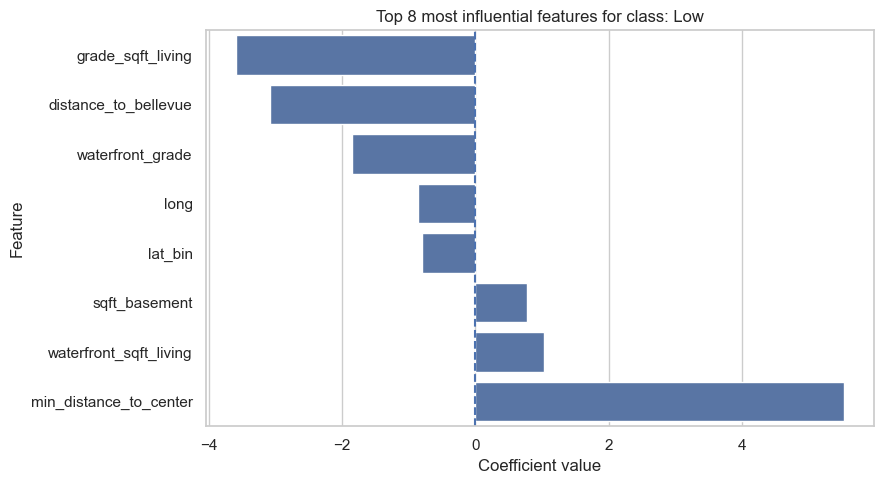

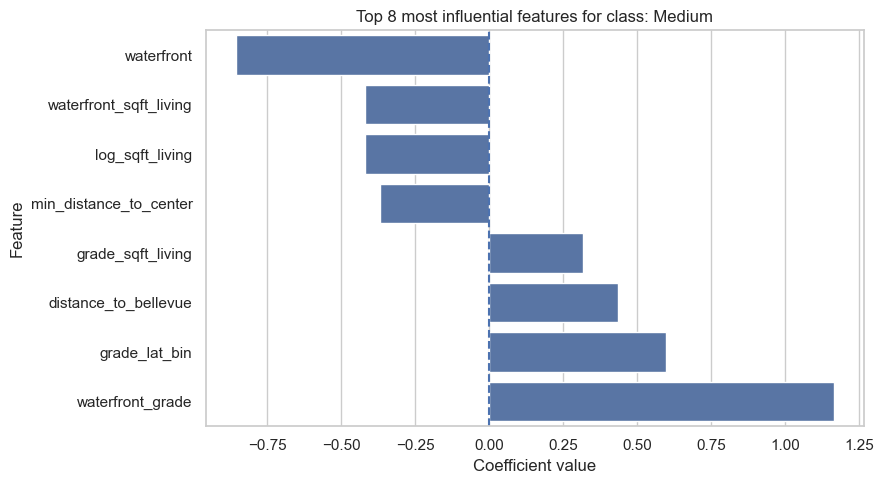

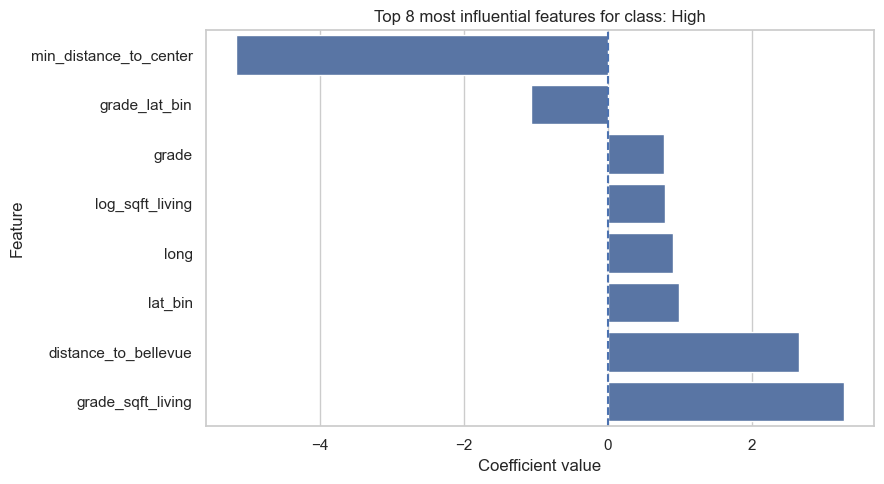

In [12]:
top_n = 8

for class_name in class_labels:
    class_coefficients = coef_df.loc[class_name]

    top_features = class_coefficients.abs().sort_values(ascending=False).head(top_n).index
    top_coefficients = class_coefficients.loc[top_features].sort_values()

    plt.figure(figsize=(9, 5))
    sns.barplot(
        x=top_coefficients.values,
        y=top_coefficients.index
    )

    plt.axvline(0, linestyle="--")
    plt.title(f"Top {top_n} most influential features for class: {class_name}")
    plt.xlabel("Coefficient value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

### Interpretim: koeficientet e Logistic Regression

Tabela e koeficienteve tregon se si secila veçori ndikon ne drejtimin e parashikimit per secilen klase. Koeficientet pozitive e shtyjne modelin drejt asaj klase, ndersa koeficientet negative e largojne modelin nga ajo klase. Meqenese te dhenat jane te shkallezuara, madhesite e koeficienteve mund te krahasohen me mire mes veçorive.

Per klasen `High`, disa nga koeficientet me ndikim pozitiv jane `grade`, `waterfront_grade`, `condition`, `view_grade` dhe `grade_location_cluster`. Kjo tregon se cilesia e shtepise, pamja/lidhja me waterfront dhe lokacioni ndikojne ne rritjen e probabilitetit qe nje prone te klasifikohet si `High`. Nga ana tjeter, koeficienti negativ per `grade_lat_bin` dhe disa veçori te madhesise tregon se ndikimi i veçorive nuk eshte gjithmone i thjeshte individualisht, sepse disa prej tyre jane kombinime ose lidhen me veçori te tjera.

Per klasen `Low`, koeficientet pozitive si `waterfront`, `sqft_living`, `location_cluster` dhe `grade_lat_bin` duhet interpretuar me kujdes, sepse Logistic Regression punon me te gjitha veçorite njekohesisht dhe disa features jane te korreluara. Koeficientet negative si `grade`, `bathrooms`, `condition`, `waterfront_grade` dhe `grade_location_cluster` tregojne se cilesia me e larte dhe disa tregues premium e ulin probabilitetin qe prona te jete ne klasen `Low`.

Per klasen `Medium`, koeficientet jane me te balancuar dhe zakonisht me te vegjel, qe eshte e pritshme sepse `Medium` eshte klase ndermjetese. Kjo lidhet edhe me confusion matrix, ku `Medium` ishte klasa me me shume mbivendosje me `Low` dhe `High`.

Ne pergjithesi, koeficientet konfirmojne se modeli perdor kryesisht kombinime te cilesise se prones, lokacionit, waterfront/view dhe madhesise per te ndare klasat e cmimit. Megjithate, koeficientet nuk tregojne shkakesi direkte; ata tregojne ndikimin relativ te veçorive brenda modelit linear, duke marre parasysh edhe veçorite e tjera.

## 9. Ruajtja e rezultateve
 
 Rezultatet ruhen qe te perdoren me vone ne tabelen krahasuese finale me modelet  tjera.

In [13]:
results_dir = data_dir / "model_results"
results_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame([test_metrics]).to_csv(results_dir / "logistic_regression_results.csv", index=False)
pd.DataFrame({"selected_features": final_selected_features}).to_csv(
    results_dir / "logistic_regression_selected_features.csv",
    index=False,
)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[f"true_{label}" for label in class_labels],
    columns=[f"pred_{label}" for label in class_labels],
)
confusion_matrix_df.to_csv(results_dir / "logistic_regression_confusion_matrix.csv")

classification_report_df = pd.DataFrame(
    classification_report(y_test, test_pred, labels=class_labels, output_dict=True, zero_division=0)
).transpose()
classification_report_df.to_csv(results_dir / "logistic_regression_classification_report.csv")

feature_selection_df.to_csv(results_dir / "logistic_regression_feature_selection_results.csv", index=False)
train_vs_val_results.to_csv(results_dir / "logistic_regression_train_vs_validation.csv", index=False)
coef_df.to_csv(results_dir / "logistic_regression_coefficients.csv")

print("Results saved to:", results_dir)
print("- logistic_regression_results.csv")
print("- logistic_regression_selected_features.csv")
print("- logistic_regression_confusion_matrix.csv")
print("- logistic_regression_classification_report.csv")
print("- logistic_regression_feature_selection_results.csv")
print("- logistic_regression_train_vs_validation.csv")
print("- logistic_regression_coefficients.csv")

Results saved to: ..\..\data\processed\model_results
- logistic_regression_results.csv
- logistic_regression_selected_features.csv
- logistic_regression_confusion_matrix.csv
- logistic_regression_classification_report.csv
- logistic_regression_feature_selection_results.csv
- logistic_regression_train_vs_validation.csv
- logistic_regression_coefficients.csv


## 10. Kufizime dhe perfundim

Logistic Regression rezultoi model solid dhe i interpretueshem per klasifikimin e cmimeve te shtepive ne klasat `Low`, `Medium` dhe `High`. Modeli final u trajnua me train + validation dhe arriti Accuracy = 0.8011, Precision Macro = 0.8054, Recall Macro = 0.8008 dhe F1 Macro = 0.8024 ne test set. Keto rezultate tregojne se modeli arrin performance te mire dhe te balancuar per nje model linear.

Nga krahasimi train vs validation nuk u pane shenja te forta overfitting. Train F1 Macro ishte 0.8014, ndersa Validation F1 Macro ishte 0.8090, me gap -0.0076. Kjo tregon se modeli nuk eshte pershtatur teper me train set-in dhe gjeneralizon mire ne validation. Fakti qe validation performon pak me mire se train mund te vije nga ndarja e te dhenave ose nga raste pak me te lehta ne validation set.

Eksperimenti me zgjedhje vecorish tregoi se `all_features` performoi me mire se variantet me `SelectKBest`. Modeli final perdori 52 features, qe sugjeron se edhe vecorite qe nuk jane me te forta individualisht mund te ndihmojne kur kombinohen ne nje model linear. Kjo eshte e arsyeshme, sepse dataset-i permban shume vecori te krijuara nga feature engineering, si kombinime te madhesise, lokacionit dhe `grade`.

Nga confusion matrix u pa se modeli klasifikon mire klasat ekstreme `Low` dhe `High`. Gabimet direkte mes tyre jane shume te vogla: vetem 7 raste `Low` u parashikuan si `High`, dhe vetem 5 raste `High` u parashikuan si `Low`. Gabimet kryesore lidhen me klasen `Medium`, ku disa raste `Medium` parashikohen si `Low` ose `High`, dhe disa raste ekstreme kalojne ne `Medium`. Kjo tregon se klasa `Medium` ka mbivendosje me dy klasat e tjera dhe eshte me e veshtira per t'u ndare qarte.

Nje avantazh kryesor i Logistic Regression eshte interpretueshmeria. Koeficientet e modelit tregojne drejtimin dhe fuqine relative te ndikimit te vecorive per secilen klase. Nga koeficientet shihet se modeli perdor kombinime te cilesise se prones, lokacionit, madhesise, waterfront/view dhe `grade` per te ndare klasat e cmimit. Megjithate, koeficientet duhet interpretuar me kujdes, sepse disa features jane te korreluara ose te krijuara nga kombinime te tjera. Ata tregojne lidhje brenda modelit, jo shkakesi direkte.

Kufizimi kryesor i Logistic Regression eshte se eshte model linear. Ai mund te mos kape mire marredhenie komplekse dhe jo-lineare mes lokacionit, madhesise, `grade` dhe cmimit. Per kete arsye, performanca e tij eshte me e ulet se modelet me komplekse si Random Forest. Megjithate, per shkak te thjeshtesise, stabilitetit, mungeses se overfitting dhe interpretueshmerise, Logistic Regression sherben si baseline i forte dhe i dobishem per krahasim me modelet tjera.